In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from src.data.collector import F1DataCollector
from src.data.preprocessor import LapPreprocessor
from src.features.imaging import TelemetryImager

%matplotlib inline

In [2]:
collector = F1DataCollector()
collector.load_session(2025, 'Bahrain Grand Prix')

laps = collector.session.laps
preprocessor = LapPreprocessor(laps)
clean_laps = preprocessor.filter_laps(laps)
clean_laps = preprocessor.label_laps(clean_laps)

print(f"Clean laps: {len(clean_laps)}")
print(f"Anomalous: {clean_laps['is_anomaly'].sum()}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.4.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63: Lap timing integrity check failed for 3 lap(s)
logger      WARNING 	Failed to add first lap time from Ergast!
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for 

Clean laps: 1023
Anomalous: 61


In [3]:
imager = TelemetryImager(n_bins=200)

lap = clean_laps.iloc[10]
tel = collector.get_telemetry(lap)
image = imager.lap_to_image(tel, preprocessor)

print(f"Image shape: {image.shape}")  # should be (5, 200)

Image shape: (5, 200)


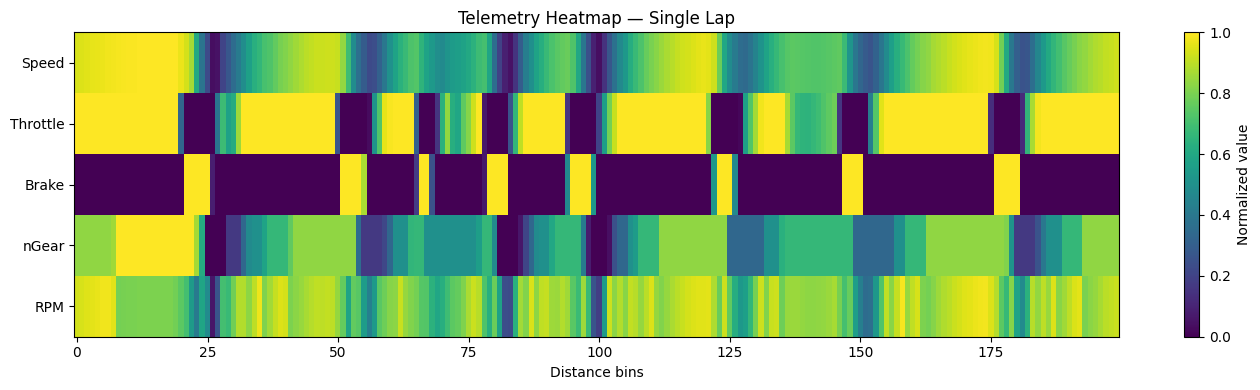

In [4]:
signals = ['Speed', 'Throttle', 'Brake', 'nGear', 'RPM']

plt.figure(figsize=(14, 4))
plt.imshow(image, aspect='auto', cmap='viridis')
plt.yticks(range(5), signals)
plt.xlabel('Distance bins')
plt.title('Telemetry Heatmap — Single Lap')
plt.colorbar(label='Normalized value')
plt.tight_layout()
plt.show()

In [5]:
import joblib

collector_25 = F1DataCollector()
collector_25.load_session(2025, 'Bahrain Grand Prix')

laps_25 = collector_25.session.laps
preprocessor_25 = LapPreprocessor(laps_25)
clean_laps_25 = preprocessor_25.filter_laps(laps_25)
clean_laps_25 = preprocessor_25.label_laps(clean_laps_25)

print(f"Clean laps: {len(clean_laps_25)}")
print(f"Anomalous: {clean_laps_25['is_anomaly'].sum()}")

images, labels = [], []

for _, lap in clean_laps_25.iterrows():
    try:
        tel = collector_25.get_telemetry(lap)
        img = imager.lap_to_image(tel, preprocessor_25)
        images.append(img)
        labels.append(int(lap['is_anomaly']))
    except Exception as e:
        continue

images = np.array(images)
labels = np.array(labels)

print(f"Dataset shape: {images.shape}")  # (n_laps, 5, 200)
print(f"Labels: {labels.sum()} anomalous / {len(labels)} total")

os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/images.npy', images)
np.save('../data/processed/labels.npy', labels)
print("Saved to data/processed/")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.4.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63: Lap timing integrity check failed for 3 lap(s)
logger      WARNING 	Failed to add first lap time from Ergast!
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for 

Clean laps: 1023
Anomalous: 61
Dataset shape: (1023, 5, 200)
Labels: 61 anomalous / 1023 total
Saved to data/processed/
